# Backbone Comparison Lab
Run and compare `patch` vs `roi_patch` backbones.
This notebook reuses existing runs when available and visualizes: final per-task metrics, stage-wise behavior maps/trajectories, and failure diagnostics from confusion artifacts.

In [19]:
from pathlib import Path
import subprocess
import sys

project_root = Path.cwd()
if (project_root / 'train.py').exists() is False:
    project_root = project_root.parent

cmd = [
    sys.executable,
    str(project_root / 'lab' / 'run_backbone_comparison.py'),
    '--backbones', 'patch', 'roi_patch',
    '--patch-prototype-mode', 'class_position_ema',
    '--prototype-momentum', '0.9',
    '--patch-proto-sharpness', '1.0',
    '--lambda-prd', '1.0',
    '--epochs', '2',
    '--linear-epochs', '2',
    '--batch-size', '128',
    '--replay-size', '1000',
    '--seed', '42',
    '--device', 'auto',
    '--step-eval-every', '25',
    '--max-step-eval-batches', '3',
    '--require-complete-task4',
    '--enable-csv',
]

print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True, cwd=project_root)

Running: /Users/pengu/Developer/pprd-refactor/.venv/bin/python /Users/pengu/Developer/pprd-refactor/lab/run_backbone_comparison.py --backbones patch roi_patch --patch-prototype-mode class_position_ema --prototype-momentum 0.9 --patch-proto-sharpness 1.0 --lambda-prd 1.0 --epochs 2 --linear-epochs 2 --batch-size 128 --replay-size 1000 --seed 42 --device auto --step-eval-every 25 --max-step-eval-batches 3 --require-complete-task4 --enable-csv


Seed set to 42
/Users/pengu/Developer/pprd-refactor/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Run directory: logs/2026-04-21/lab_patch_class-position-ema_e2_le2_b128_r1000_s42
Run name: lab_patch_class-position-ema_e2_le2_b128_r1000_s42
Run id: e39d7bfaaa85
Task classes: [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
Device: mps
Lightning accelerator=mps, devices=1, precision=32


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..

  | Name          | Type                   | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0 | model         | PrototypePatchBackbone | 11.5 M | train | 0    
1 | criterion_nce | ISSupConLoss           | 0      | train | 0    
2 | criterion_ce  | CrossEntropyLoss       | 0      | train | 0    
-------------------------------------------------------------------------
11.5 M    Trainable params
0         Non-trainable params
11.5 M    Total params
46.024    Total estimated model params size (MB)
76        Modules in train mode
0         

Epoch 1: 100%|██████████| 79/79 [01:09<00:00,  1.14it/s, v_num=0, train/loss_step=4.340, train/loss_epoch=6.580]

...

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..

  | Name          | Type                   | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0 | model         | PrototypePatchBackbone | 11.5 M | train | 0    
1 | old_model     | PrototypePatchBackbone | 11.5 M | eval  | 0    
2 | criterion_nce | ISSupConLoss           | 0      | train | 0    
3 | criterion_ce  | CrossEntropyLoss       | 0      | train | 0    
-------------------------------------------------------------------------
11.5 M    Trainable params
11.5 M    Non-trainable params
23.0 M    Total params
92.049    Total estimat

Epoch 1: 100%|██████████| 86/86 [03:41<00:00,  0.39it/s, v_num=0, train/loss_step=7.580, train/loss_epoch=7.850]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 86/86 [03:41<00:00,  0.39it/s, v_num=0, train/loss_step=7.580, train/loss_epoch=7.850]
Task 4 | Epochs: 2 | Avg Loss: 7.8528
[Seen Task Eval] after task 4 | task 0 | loss=1.7321 | acc=31.80% | forgetting=54.00%
[Seen Task Eval] after task 4 | task 1 | loss=2.2137 | acc=8.90% | forgetting=38.70%
[Seen Task Eval] after task 4 | task 2 | loss=2.0553 | acc=9.40% | forgetting=57.45%
[Seen Task Eval] after task 4 | task 3 | loss=1.9527 | acc=49.60% | forgetting=12.50%
[Seen Task Eval] after task 4 | task 4 | loss=1.6224 | acc=50.80% | forgetting=0.00%
[Seen Summary] after task 4 | avg_loss=1.9152 | avg_acc=30.10% | mean_forgetting=32.53%
[Behavior] stage task 4 -> T0: acc=31.80% loss=1.7321 fg=54.00% | T1: acc=8.90% loss=2.2137 fg=38.70% | T2: acc=9.40% loss=2.0553 fg=57.45% | T3: acc=49.60% loss=1.9527 fg=12.50% | T4: acc=50.80% loss=1.6224 fg=0.00%
[Linear Eval] up to task 4: 30.10%
Continual training completed.
[roi_patch] reused=False | recovered_ckpt=False | co

CompletedProcess(args=['/Users/pengu/Developer/pprd-refactor/.venv/bin/python', '/Users/pengu/Developer/pprd-refactor/lab/run_backbone_comparison.py', '--backbones', 'patch', 'roi_patch', '--patch-prototype-mode', 'class_position_ema', '--prototype-momentum', '0.9', '--patch-proto-sharpness', '1.0', '--lambda-prd', '1.0', '--epochs', '2', '--linear-epochs', '2', '--batch-size', '128', '--replay-size', '1000', '--seed', '42', '--device', 'auto', '--step-eval-every', '25', '--max-step-eval-batches', '3', '--require-complete-task4', '--enable-csv'], returncode=0)

In [20]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

comparison_path = project_root / 'lab' / 'results' / 'backbone_comparison.json'
with open(comparison_path, 'r', encoding='utf-8') as f:
    comparison = json.load(f)

df = pd.DataFrame(comparison['records'])

def resolve_artifact_path(path_value):
    if path_value is None:
        return None
    text = str(path_value).strip()
    if not text:
        return None
    p = Path(text)
    if not p.is_absolute():
        p = (project_root / p).resolve()
    return p

for col in ['summary_path', 'tasks_path', 'step_eval_path', 'diagnostics_path', 'combined_path']:
    if col in df.columns:
        df[f'{col}_resolved'] = df[col].apply(resolve_artifact_path)

for col in ['final_seen_avg_accuracy', 'final_mean_forgetting', 'final_seen_avg_loss']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

expected = {'patch', 'roi_patch'}
found = set(df['backbone'].astype(str).tolist())
print('Found backbones:', sorted(found))
missing = expected - found
if missing:
    print('Missing backbones in comparison file:', sorted(missing))

if 'step_eval_path_resolved' in df.columns:
    missing_step_paths = df[~df['step_eval_path_resolved'].apply(lambda p: p is not None and p.exists())]['backbone'].astype(str).tolist()
    if missing_step_paths:
        print('Warning: missing step-eval files for backbones:', sorted(missing_step_paths))

df

Found backbones: ['patch', 'roi_patch']


,backbone,run_name,task_order,task_classes,summary_path,tasks_path,step_eval_path,diagnostics_path,combined_path,reused_existing,...,is_complete_task4,eval_task_id,final_seen_avg_accuracy,final_seen_avg_loss,final_mean_forgetting,summary_path_resolved,tasks_path_resolved,step_eval_path_resolved,diagnostics_path_resolved,combined_path_resolved
0,patch,lab_patch_class-position-ema_e2_le2_b128_r1000...,None,"[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]",/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,False,...,True,None,31.15,1.861314,36.29,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...
1,roi_patch,lab_roi_patch_class-position-ema_e2_le2_b128_r...,None,"[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]",/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,False,...,True,None,30.10,1.915245,32.53,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...,/Users/pengu/Developer/pprd-refactor/logs/2026...


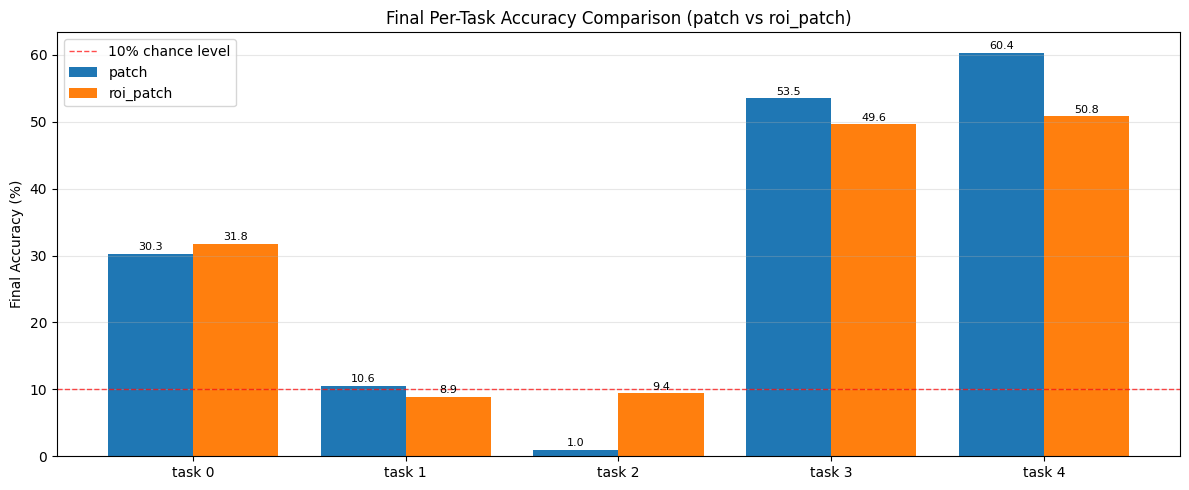

Final per-task accuracy report:


backbone,patch,roi_patch
task_id,,
0,30.30,31.8
1,10.55,8.9
2,1.00,9.4
3,53.55,49.6
4,60.35,50.8


In [21]:
# Final per-task accuracy comparison (both backbones in one chart)
import numpy as np

task_records = []
history_records = []
missing_task_metrics = []
metrics_source = 'tasks_artifacts'

def _safe_int(value, default=-1):
    try:
        return int(value)
    except Exception:
        return default

def _load_tasks_payload(tasks_path, combined_path):
    if tasks_path is not None and tasks_path.exists():
        with open(tasks_path, 'r', encoding='utf-8') as f:
            payload = json.load(f)
        if isinstance(payload, list):
            return payload

    if combined_path is not None and combined_path.exists():
        with open(combined_path, 'r', encoding='utf-8') as f:
            payload = json.load(f)
        if isinstance(payload, dict) and isinstance(payload.get('tasks'), list):
            return payload['tasks']

    return None

for _, row in df.iterrows():
    backbone = str(row.get('backbone', 'unknown'))
    tasks_path = row.get('tasks_path_resolved', None)
    combined_path = row.get('combined_path_resolved', None)

    tasks_payload = _load_tasks_payload(tasks_path, combined_path)
    if not isinstance(tasks_payload, list) or len(tasks_payload) == 0:
        missing_task_metrics.append(backbone)
        continue

    valid_stages = [stage for stage in tasks_payload if isinstance(stage, dict)]
    if not valid_stages:
        missing_task_metrics.append(backbone)
        continue

    for stage in valid_stages:
        stage_task_id = _safe_int(stage.get('task_id', -1), default=-1)
        seen_metrics = stage.get('seen_task_metrics', [])
        if not isinstance(seen_metrics, list):
            continue
        for metric in seen_metrics:
            if not isinstance(metric, dict):
                continue
            task_id = _safe_int(metric.get('task_id', -1), default=-1)
            history_records.append(
                {
                    'backbone': backbone,
                    'stage_task_id': stage_task_id,
                    'task_id': task_id,
                    'accuracy': pd.to_numeric(metric.get('accuracy', np.nan), errors='coerce'),
                    'loss': pd.to_numeric(metric.get('loss', np.nan), errors='coerce'),
                    'forgetting': pd.to_numeric(metric.get('forgetting', np.nan), errors='coerce'),
                }
            )

    final_stage = max(valid_stages, key=lambda s: _safe_int(s.get('task_id', -1), default=-1))
    final_seen = final_stage.get('seen_task_metrics', [])
    if not isinstance(final_seen, list):
        continue

    for metric in final_seen:
        if not isinstance(metric, dict):
            continue
        task_id = _safe_int(metric.get('task_id', -1), default=-1)
        task_records.append(
            {
                'backbone': backbone,
                'task_id': task_id,
                'accuracy': pd.to_numeric(metric.get('accuracy', np.nan), errors='coerce'),
                'loss': pd.to_numeric(metric.get('loss', np.nan), errors='coerce'),
                'forgetting': pd.to_numeric(metric.get('forgetting', np.nan), errors='coerce'),
            }
        )

final_task_df = pd.DataFrame(task_records)
task_history_df = pd.DataFrame(history_records)

# Fallback when per-stage tasks artifacts are unavailable but step_all exists in kernel.
if final_task_df.empty and 'step_all' in globals() and isinstance(step_all, pd.DataFrame) and not step_all.empty:
    metrics_source = 'step_all_fallback'
    print('Warning: using step_all fallback (raw step-eval logits), not final linear-eval tasks metrics.')
    print('This can make accuracies look artificially equal/near chance. Re-run Cell 1 to regenerate tasks artifacts for true final per-task comparison.')
    fb = step_all.copy()
    fb['task_id'] = pd.to_numeric(fb.get('seen_task_id', np.nan), errors='coerce')
    fb['global_step'] = pd.to_numeric(fb.get('global_step', np.nan), errors='coerce')
    fb['accuracy'] = pd.to_numeric(fb.get('accuracy', np.nan), errors='coerce')
    fb['loss'] = pd.to_numeric(fb.get('loss', np.nan), errors='coerce')
    fb = fb.dropna(subset=['task_id', 'global_step', 'accuracy'])

    if not fb.empty:
        fb_last = fb.sort_values('global_step').groupby(['backbone', 'task_id'], as_index=False).tail(1)
        final_task_df = fb_last[['backbone', 'task_id', 'accuracy', 'loss']].copy()
        if 'forgetting' in fb_last.columns:
            final_task_df['forgetting'] = pd.to_numeric(fb_last['forgetting'], errors='coerce')
        else:
            final_task_df['forgetting'] = np.nan

        history_stage_col = 'stage_task_id' if 'stage_task_id' in fb.columns else 'global_step'
        task_history_df = fb[['backbone', history_stage_col, 'task_id', 'accuracy', 'loss']].copy()
        task_history_df = task_history_df.rename(columns={history_stage_col: 'stage_task_id'})
        task_history_df['forgetting'] = pd.to_numeric(fb.get('forgetting', np.nan), errors='coerce')

if final_task_df.empty:
    print('No per-task metrics available to plot.')
else:
    final_task_df['task_id'] = pd.to_numeric(final_task_df['task_id'], errors='coerce')
    final_task_df['accuracy'] = pd.to_numeric(final_task_df['accuracy'], errors='coerce')
    final_task_df = final_task_df.dropna(subset=['task_id', 'accuracy'])
    final_task_df['task_id'] = final_task_df['task_id'].astype(int)

    backbones = sorted(final_task_df['backbone'].astype(str).unique().tolist())
    task_ids = sorted(final_task_df['task_id'].unique().tolist())

    x = np.arange(len(task_ids))
    width = 0.8 / max(1, len(backbones))

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, backbone_name in enumerate(backbones):
        sub = final_task_df[final_task_df['backbone'] == backbone_name].set_index('task_id')
        vals = [sub['accuracy'].get(task_id, float('nan')) for task_id in task_ids]
        offset = (i - (len(backbones) - 1) / 2.0) * width
        bars = ax.bar(x + offset, vals, width=width, label=backbone_name)

        for bar, value in zip(bars, vals):
            if pd.notna(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    value + 0.2,
                    f'{value:.1f}',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                )

    ax.axhline(10.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='10% chance level')
    ax.set_xticks(x)
    ax.set_xticklabels([f'task {task_id}' for task_id in task_ids])
    ax.set_ylabel('Final Accuracy (%)')
    title_suffix = ' (fallback: step-eval)' if metrics_source == 'step_all_fallback' else ''
    ax.set_title(f'Final Per-Task Accuracy Comparison (patch vs roi_patch){title_suffix}')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Final per-task accuracy report:')
    report_df = (
        final_task_df.pivot_table(index='task_id', columns='backbone', values='accuracy', aggfunc='mean')
        .sort_index()
    )
    display(report_df)

if missing_task_metrics:
    print('Backbones missing tasks artifacts (used fallback when possible):', sorted(set(missing_task_metrics)))

In [22]:
# Diagnose why a task can end near or below ~10% final accuracy
threshold = 10.0

if 'final_task_df' not in globals() or final_task_df.empty:
    print('Run the per-task comparison cell first (Cell 4).')
else:
    low_df = final_task_df[final_task_df['accuracy'] < threshold].copy()
    if low_df.empty:
        print('No final-stage tasks are below 10% accuracy in the current comparison.')
    else:
        print(f'Tasks below {threshold:.1f}% final accuracy:')
        display(
            low_df[['backbone', 'task_id', 'accuracy', 'loss', 'forgetting']]
            .sort_values(['backbone', 'task_id'])
            .reset_index(drop=True)
        )

        if metrics_source == 'step_all_fallback':
            print('Note: this diagnosis is based on step-level fallback metrics (raw model logits), not final linear-eval task summaries.')
            print('If you see suspiciously equal accuracies, run Cell 1 first to regenerate tasks artifacts and then re-run Cells 3-5.')

        if 'task_history_df' in globals() and not task_history_df.empty:
            hist = task_history_df.copy()
            hist['stage_task_id'] = pd.to_numeric(hist['stage_task_id'], errors='coerce')
            hist['task_id'] = pd.to_numeric(hist['task_id'], errors='coerce')
            hist['accuracy'] = pd.to_numeric(hist['accuracy'], errors='coerce')
            hist['loss'] = pd.to_numeric(hist.get('loss', np.nan), errors='coerce')
            hist = hist.dropna(subset=['stage_task_id', 'task_id', 'accuracy'])
            hist['stage_task_id'] = hist['stage_task_id'].astype(int)
            hist['task_id'] = hist['task_id'].astype(int)

            insight_rows = []
            for _, row in low_df.iterrows():
                backbone_name = str(row['backbone'])
                task_id = int(row['task_id'])
                final_acc = float(row['accuracy'])

                h = hist[(hist['backbone'] == backbone_name) & (hist['task_id'] == task_id)].sort_values('stage_task_id')
                if h.empty:
                    continue

                peak_idx = h['accuracy'].idxmax()
                peak_row = h.loc[peak_idx]
                peak_acc = float(peak_row['accuracy'])
                peak_stage = int(peak_row['stage_task_id'])

                final_row = h.iloc[-1]
                final_stage = int(final_row['stage_task_id'])
                final_loss = float(final_row['loss']) if pd.notna(final_row['loss']) else float('nan')
                drop_pp = peak_acc - final_acc

                insight_rows.append(
                    {
                        'backbone': backbone_name,
                        'task_id': task_id,
                        'peak_acc_%': peak_acc,
                        'peak_stage': peak_stage,
                        'final_acc_%': final_acc,
                        'final_stage': final_stage,
                        'drop_pp': drop_pp,
                        'final_loss': final_loss,
                    }
                )

            if insight_rows:
                insight_df = pd.DataFrame(insight_rows).sort_values(['backbone', 'task_id']).reset_index(drop=True)
                print('Low-accuracy diagnosis (peak-to-final drop):')
                display(insight_df)

                print('Interpretation:')
                print('- ~10% is chance-level behavior for a 10-class evaluation setup.')
                print('- If a task had much higher peak accuracy earlier but ends near/below 10%, this indicates strong forgetting/interference after later tasks.')
                print('- High final loss together with low final accuracy means that task-specific decision boundaries are no longer preserved at the final stage.')
            else:
                print('Not enough history to compute peak-to-final diagnostics.')
        else:
            print('Task history is unavailable, so only final low-accuracy tasks are reported.')

Tasks below 10.0% final accuracy:


,backbone,task_id,accuracy,loss,forgetting
0,patch,2,1.0,2.040985,70.00
1,roi_patch,1,8.9,2.213709,38.70
2,roi_patch,2,9.4,2.055308,57.45


Low-accuracy diagnosis (peak-to-final drop):


,backbone,task_id,peak_acc_%,peak_stage,final_acc_%,final_stage,drop_pp,final_loss
0,patch,2,71.00,2,1.0,4,70.00,2.040985
1,roi_patch,1,47.60,1,8.9,4,38.70,2.213709
2,roi_patch,2,66.85,2,9.4,4,57.45,2.055308


Interpretation:
- ~10% is chance-level behavior for a 10-class evaluation setup.
- If a task had much higher peak accuracy earlier but ends near/below 10%, this indicates strong forgetting/interference after later tasks.
- High final loss together with low final accuracy means that task-specific decision boundaries are no longer preserved at the final stage.


In [23]:
step_frames = []
missing_step = []

for _, row in df.iterrows():
    summary_path = row.get('summary_path_resolved', None)
    step_path = row.get('step_eval_path_resolved', None)
    combined_path = row.get('combined_path_resolved', None)

    if step_path is None and summary_path is not None:
        step_path = summary_path.parent / 'results_step_eval.json'

    step_data = None
    used_source = None

    if step_path is not None and step_path.exists():
        with open(step_path, 'r', encoding='utf-8') as f:
            step_data = json.load(f)
        used_source = step_path
    elif combined_path is not None and combined_path.exists():
        with open(combined_path, 'r', encoding='utf-8') as f:
            combined_data = json.load(f)
        if isinstance(combined_data, dict) and isinstance(combined_data.get('step_eval'), list):
            step_data = combined_data['step_eval']
            used_source = combined_path

    if not isinstance(step_data, list) or len(step_data) == 0:
        missing_step.append((row['backbone'], str(step_path) if step_path is not None else 'None'))
        continue

    step_df = pd.DataFrame(step_data)
    if step_df.empty:
        missing_step.append((row['backbone'], str(step_path) if step_path is not None else 'None'))
        continue

    step_df['backbone'] = row['backbone']
    step_df['step_source'] = str(used_source) if used_source is not None else ''
    step_frames.append(step_df)

if missing_step:
    print('Missing/empty step files:')
    for backbone, path in missing_step:
        print('-', backbone, path)

step_all = pd.concat(step_frames, ignore_index=True) if step_frames else pd.DataFrame()
step_all.head()

,stage_task_id,global_step,seen_task_id,loss,accuracy,forgetting,backbone,step_source
0,0.0,25.0,0.0,1.000388,58.593750,0.000000,patch,/Users/pengu/Developer/pprd-refactor/logs/2026...
1,0.0,50.0,0.0,0.518365,77.604167,0.000000,patch,/Users/pengu/Developer/pprd-refactor/logs/2026...
2,0.0,75.0,0.0,0.899660,72.395833,5.208333,patch,/Users/pengu/Developer/pprd-refactor/logs/2026...
3,0.0,100.0,0.0,0.387963,82.031250,0.000000,patch,/Users/pengu/Developer/pprd-refactor/logs/2026...
4,0.0,125.0,0.0,0.317304,85.937500,0.000000,patch,/Users/pengu/Developer/pprd-refactor/logs/2026...


In [24]:
# Coverage diagnostics: check whether both backbones have comparable step/task traces
if step_all.empty:
    print('No step eval data found.')
else:
    diag = (
        step_all.groupby('backbone')
        .agg(
            rows=('global_step', 'size'),
            unique_steps=('global_step', 'nunique'),
            min_step=('global_step', 'min'),
            max_step=('global_step', 'max'),
            unique_tasks=('seen_task_id', 'nunique')
        )
        .reset_index()
    )
    display(diag)

    if len(diag) >= 2 and diag['unique_steps'].min() < diag['unique_steps'].max():
        print(
            'Step coverage mismatch detected. Re-run Cell 1 to let the runner precheck existing checkpoints. '
            'Add --require-complete-task4 in Cell 1 if you want forced full reruns.'
        )

,backbone,rows,unique_steps,min_step,max_step,unique_tasks
0,patch,90,30,25.0,824.0,5
1,roi_patch,90,30,25.0,824.0,5


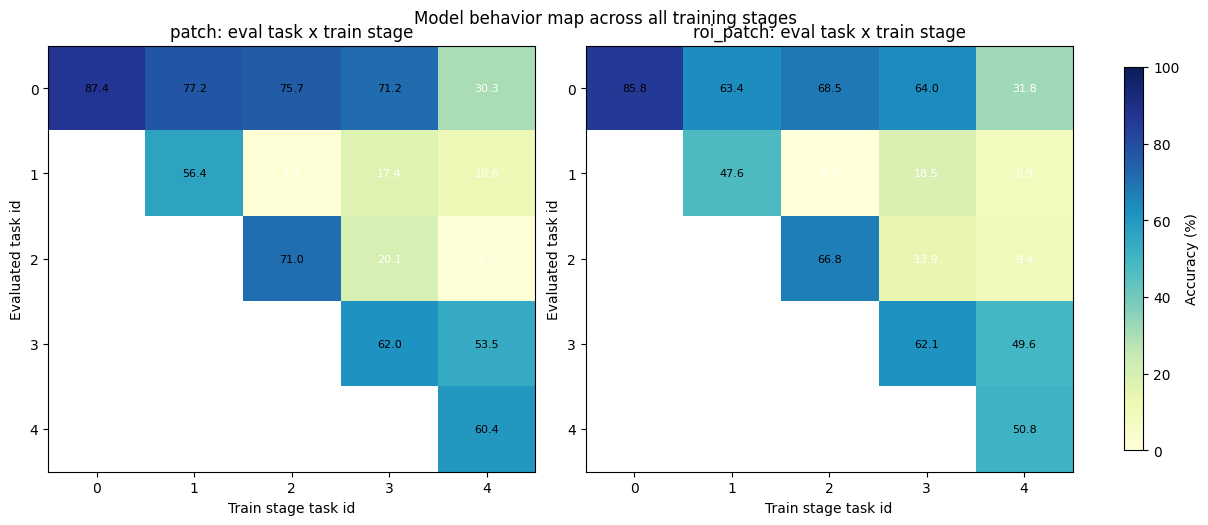

In [25]:
# Behavior Figure 1: Task-vs-stage accuracy heatmap (linear eval)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'task_history_df' not in globals() or task_history_df.empty:
    print('Run Cell 4 first to build task history from results_tasks artifacts.')
else:
    work = task_history_df.copy()
    work['stage_task_id'] = pd.to_numeric(work['stage_task_id'], errors='coerce')
    work['task_id'] = pd.to_numeric(work['task_id'], errors='coerce')
    work['accuracy'] = pd.to_numeric(work['accuracy'], errors='coerce')
    work = work.dropna(subset=['backbone', 'stage_task_id', 'task_id', 'accuracy'])

    work['stage_task_id'] = work['stage_task_id'].astype(int)
    work['task_id'] = work['task_id'].astype(int)
    backbones = sorted(work['backbone'].astype(str).unique().tolist())

    fig, axes = plt.subplots(
        1,
        len(backbones),
        figsize=(6 * max(1, len(backbones)), 5),
        squeeze=False,
        constrained_layout=True,
    )
    image_handle = None

    for idx, backbone_name in enumerate(backbones):
        ax = axes[0][idx]
        sub = work[work['backbone'] == backbone_name]
        pivot = (
            sub.groupby(['task_id', 'stage_task_id'], as_index=False)['accuracy']
            .mean()
            .pivot(index='task_id', columns='stage_task_id', values='accuracy')
            .sort_index()
            .sort_index(axis=1)
        )

        image_handle = ax.imshow(pivot.values, vmin=0.0, vmax=100.0, cmap='YlGnBu', aspect='auto')
        ax.set_title(f'{backbone_name}: eval task x train stage')
        ax.set_xlabel('Train stage task id')
        ax.set_ylabel('Evaluated task id')
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([int(v) for v in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([int(v) for v in pivot.index])

        for r, task_id in enumerate(pivot.index):
            for c, stage_task_id in enumerate(pivot.columns):
                value = pivot.loc[task_id, stage_task_id]
                if pd.isna(value):
                    continue
                text_color = 'white' if value < 45 else 'black'
                ax.text(c, r, f'{value:.1f}', ha='center', va='center', color=text_color, fontsize=8)

    if image_handle is not None:
        fig.colorbar(image_handle, ax=axes.ravel().tolist(), label='Accuracy (%)', shrink=0.9)
    fig.suptitle('Model behavior map across all training stages', y=1.02)
    plt.show()

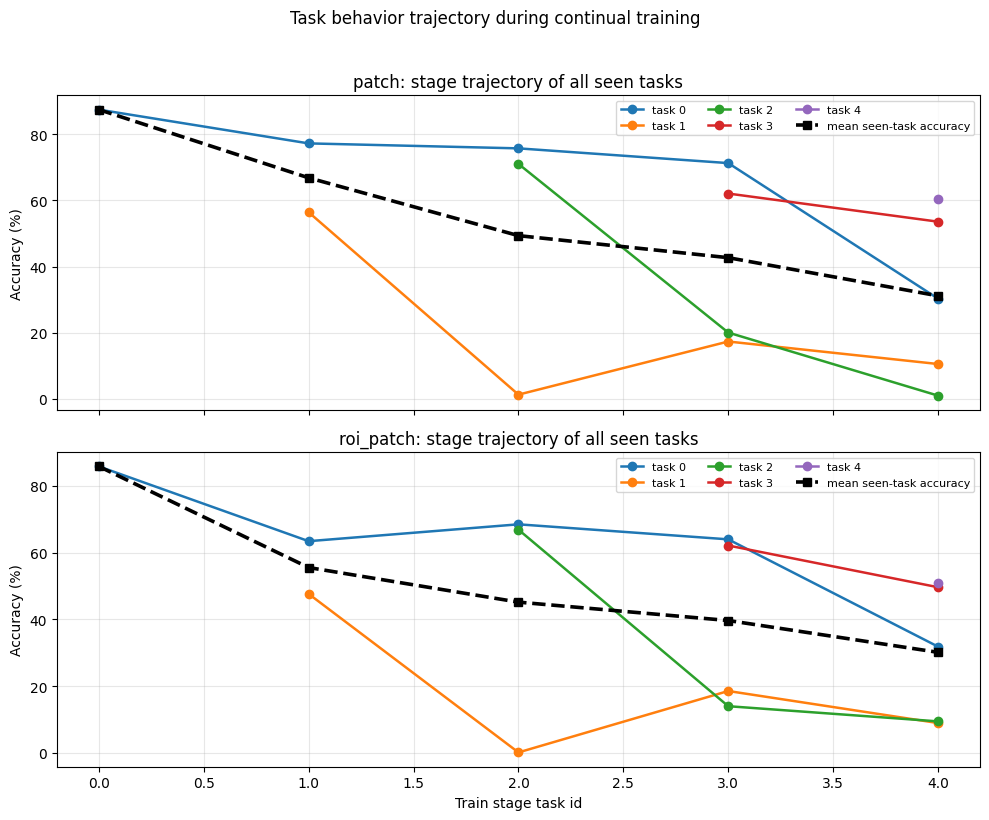

In [26]:
# Behavior Figure 2: Per-task trajectory across training stages
import pandas as pd
import matplotlib.pyplot as plt

if 'task_history_df' not in globals() or task_history_df.empty:
    print('Run Cell 4 first to build task history from results_tasks artifacts.')
else:
    work = task_history_df.copy()
    work['stage_task_id'] = pd.to_numeric(work['stage_task_id'], errors='coerce')
    work['task_id'] = pd.to_numeric(work['task_id'], errors='coerce')
    work['accuracy'] = pd.to_numeric(work['accuracy'], errors='coerce')
    work = work.dropna(subset=['backbone', 'stage_task_id', 'task_id', 'accuracy'])

    work['stage_task_id'] = work['stage_task_id'].astype(int)
    work['task_id'] = work['task_id'].astype(int)
    backbones = sorted(work['backbone'].astype(str).unique().tolist())

    fig, axes = plt.subplots(len(backbones), 1, figsize=(10, 4 * max(1, len(backbones))), sharex=True)
    if len(backbones) == 1:
        axes = [axes]

    for ax, backbone_name in zip(axes, backbones):
        sub = work[work['backbone'] == backbone_name]
        curves = (
            sub.groupby(['task_id', 'stage_task_id'], as_index=False)['accuracy']
            .mean()
            .sort_values(['task_id', 'stage_task_id'])
        )

        for task_id, task_df in curves.groupby('task_id'):
            ax.plot(task_df['stage_task_id'], task_df['accuracy'], marker='o', linewidth=1.8, label=f'task {int(task_id)}')

        mean_curve = (
            sub.groupby('stage_task_id', as_index=False)['accuracy']
            .mean()
            .sort_values('stage_task_id')
        )
        ax.plot(
            mean_curve['stage_task_id'],
            mean_curve['accuracy'],
            color='black',
            linestyle='--',
            linewidth=2.6,
            marker='s',
            label='mean seen-task accuracy',
        )

        ax.set_title(f'{backbone_name}: stage trajectory of all seen tasks')
        ax.set_ylabel('Accuracy (%)')
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=3, fontsize=8)

    axes[-1].set_xlabel('Train stage task id')
    fig.suptitle('Task behavior trajectory during continual training', y=1.02)
    plt.tight_layout()
    plt.show()

Final-stage problematic tasks (near chance):


,backbone,task_id,accuracy,chance_accuracy,seen_avg_accuracy,prediction_collapse_flag,dominant_predicted_class,max_predicted_class_ratio
0,patch,2,1.00,10.0,31.15,False,6,46.85
1,patch,1,10.55,10.0,31.15,False,6,36.60
2,roi_patch,1,8.90,10.0,30.10,False,6,28.90
3,roi_patch,2,9.40,10.0,30.10,False,6,37.40


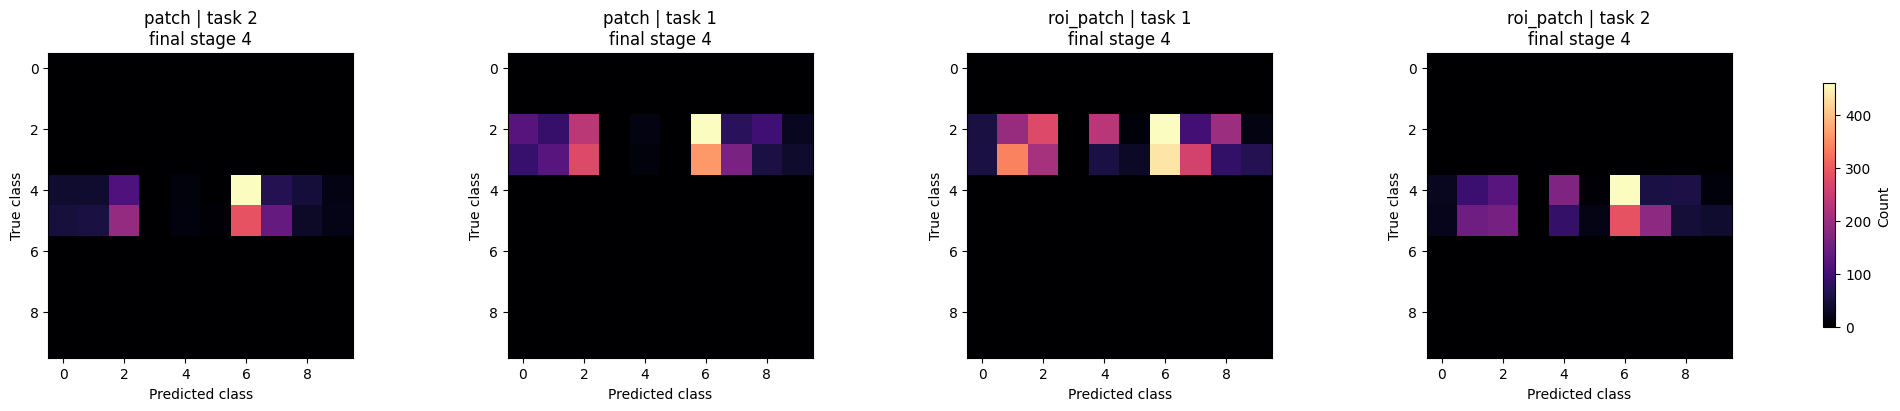

In [27]:
# Deep-dive: chance-level failures from diagnostics artifact
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'df' not in globals() or df.empty:
    print('Run Cell 3 first to load comparison records.')
else:
    diag_rows = []
    missing = []

    for _, row in df.iterrows():
        backbone_name = str(row.get('backbone', 'unknown'))
        diagnostics_path = row.get('diagnostics_path_resolved', None) if 'diagnostics_path_resolved' in df.columns else None

        if (diagnostics_path is None or not Path(diagnostics_path).exists()) and row.get('diagnostics_path', None):
            if 'resolve_artifact_path' in globals():
                diagnostics_path = resolve_artifact_path(row.get('diagnostics_path', None))

        summary_path = row.get('summary_path_resolved', None) if 'summary_path_resolved' in df.columns else None
        if (diagnostics_path is None or not Path(diagnostics_path).exists()) and summary_path is not None:
            fallback = Path(summary_path).parent / 'results_diagnostics.json'
            if fallback.exists():
                diagnostics_path = fallback

        if diagnostics_path is None or not Path(diagnostics_path).exists():
            missing.append(backbone_name)
            continue

        with open(diagnostics_path, 'r', encoding='utf-8') as f:
            payload = json.load(f)

        if not isinstance(payload, list):
            missing.append(backbone_name)
            continue

        for stage in payload:
            if not isinstance(stage, dict):
                continue
            stage_task_id = int(stage.get('stage_task_id', -1))
            stage_avg = pd.to_numeric(stage.get('seen_avg_accuracy', np.nan), errors='coerce')
            per_task = stage.get('per_task', [])
            if not isinstance(per_task, list):
                continue

            for metric in per_task:
                if not isinstance(metric, dict):
                    continue
                task_id = int(metric.get('task_id', -1))
                accuracy = pd.to_numeric(metric.get('accuracy', np.nan), errors='coerce')
                chance_accuracy = pd.to_numeric(metric.get('chance_accuracy', 10.0), errors='coerce')
                is_near_chance = bool(metric.get('is_near_chance', False))
                diag_rows.append(
                    {
                        'backbone': backbone_name,
                        'stage_task_id': stage_task_id,
                        'task_id': task_id,
                        'accuracy': accuracy,
                        'seen_avg_accuracy': stage_avg,
                        'chance_accuracy': chance_accuracy,
                        'is_near_chance': is_near_chance,
                        'prediction_collapse_flag': bool(metric.get('prediction_collapse_flag', False)),
                        'dominant_predicted_class': metric.get('dominant_predicted_class', None),
                        'max_predicted_class_ratio': pd.to_numeric(metric.get('max_predicted_class_ratio', np.nan), errors='coerce'),
                        'worst_classes': metric.get('worst_classes', []),
                        'top_confusions': metric.get('top_confusions', []),
                        'confusion_matrix': metric.get('confusion_matrix', []),
                    }
                )

    if not diag_rows:
        print('No diagnostics artifact available yet. Re-run Cell 1 after pulling the latest train.py changes.')
        if missing:
            print('Missing diagnostics for backbones:', sorted(set(missing)))
    else:
        diag_df = pd.DataFrame(diag_rows)
        diag_df = diag_df.dropna(subset=['accuracy'])

        final_stage = (
            diag_df.groupby('backbone', as_index=False)['stage_task_id']
            .max()
            .rename(columns={'stage_task_id': 'final_stage_task_id'})
        )
        final_df = diag_df.merge(final_stage, on='backbone', how='inner')
        final_df = final_df[final_df['stage_task_id'] == final_df['final_stage_task_id']].copy()

        problematic = final_df[
            (final_df['is_near_chance'])
            | (final_df['accuracy'] <= final_df['chance_accuracy'] + 2.0)
        ].copy()
        problematic = problematic.sort_values(['backbone', 'accuracy', 'task_id']).reset_index(drop=True)

        if problematic.empty:
            print('No near-chance final-stage tasks were flagged by diagnostics.')
        else:
            print('Final-stage problematic tasks (near chance):')
            display(
                problematic[
                    [
                        'backbone',
                        'task_id',
                        'accuracy',
                        'chance_accuracy',
                        'seen_avg_accuracy',
                        'prediction_collapse_flag',
                        'dominant_predicted_class',
                        'max_predicted_class_ratio',
                    ]
                ]
            )

            plot_rows = []
            for _, row in problematic.iterrows():
                cm = row.get('confusion_matrix', [])
                if isinstance(cm, list) and len(cm) > 0:
                    plot_rows.append(row)

            if plot_rows:
                max_plots = min(4, len(plot_rows))
                fig, axes = plt.subplots(
                    1,
                    max_plots,
                    figsize=(5 * max_plots, 4),
                    squeeze=False,
                    constrained_layout=True,
                )

                for idx in range(max_plots):
                    row = plot_rows[idx]
                    cm = np.array(row['confusion_matrix'], dtype=float)
                    ax = axes[0][idx]
                    img = ax.imshow(cm, cmap='magma')
                    ax.set_title(
                        f"{row['backbone']} | task {int(row['task_id'])}\nfinal stage {int(row['stage_task_id'])}"
                    )
                    ax.set_xlabel('Predicted class')
                    ax.set_ylabel('True class')

                fig.colorbar(img, ax=axes.ravel().tolist(), shrink=0.8, label='Count')
                plt.show()

        if missing:
            print('Missing diagnostics for backbones:', sorted(set(missing)))